Swarm Handoff Pattern [Step 18 - Agent-to-Agent Delegation]

> **MLCourse - Agentic AI - LangGraph**

Unlike the supervisor pattern where a central coordinator routes all traffic,
the swarm pattern lets agents hand off to each other directly. Each agent
decides independently whether it can handle the request or needs to delegate
to another agent. This creates a more decentralized and flexible system.

### What you will learn

1. How agents can hand off to other agents without a central router.
2. Implementing handoff using the `active_agent` state field.
3. Building agents that each have their own tools and expertise.
4. Visualizing the handoff graph between agents.

### Key takeaways

- Swarm agents make autonomous routing decisions.
- Handoff is triggered by the agent itself, not an external supervisor.
- This pattern scales well: adding a new agent only requires updating
  the other agents' handoff logic.

In [1]:
# --- Setup: imports, environment ---------------------------------------------

import os                           # env access
from dotenv import load_dotenv      # .env loading

load_dotenv(override=False)         # load without overriding

from typing import Annotated, TypedDict  # typed state
from langgraph.graph import StateGraph, END  # graph primitives
from langgraph.prebuilt import create_react_agent  # agent factory
from langgraph.types import Command  # for explicit handoff
from langchain_ollama import ChatOllama  # local LLM
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage  # messages
from langchain_core.tools import tool  # tool decorator

In [2]:
# --- Model guard: verify Ollama ----------------------------------------------

try:                                        # connectivity test
    _test = ChatOllama(model="llama3.1:8b", temperature=0)
    _test.invoke("ping")
    LLM_AVAILABLE = True
    print("Ollama reachable")
except Exception as exc:
    LLM_AVAILABLE = False
    print("Ollama not reachable:", exc)

Ollama reachable


In [3]:
# --- Define tools for each agent domain --------------------------------------

@tool
def search_knowledge_base(query: str) -> str:
    """Search the internal knowledge base for information.

    Args:
        query: The search query to look up in the knowledge base.
    """
    return ("KB result for '%s': Found 3 relevant entries." % query)

@tool
def write_email(subject: str, body: str) -> str:
    """Draft an email with the given subject and body.

    Args:
        subject: The email subject line.
        body: The email body text.
    """
    return "Email drafted: Subject='%s', Body length=%d chars" % (subject, len(body))

@tool
def analyze_data(data_description: str) -> str:
    """Analyze data and return insights.

    Args:
        data_description: Description of the data to analyze.
    """
    return ("Analysis of '%s': 5 key metrics, 2 anomalies, positive trend." % data_description)

In [4]:
# --- Define the swarm state with a step counter ------------------------------

class SwarmState(TypedDict):
    """State carries conversation messages and tracks the active agent."""
    messages: Annotated[list, "conversation messages"]
    active_agent: str                     # which agent is currently active
    step: int                             # safety counter to prevent loops

In [5]:
# --- Build three specialist agents --------------------------------------------

def make_llm():
    """Create a fresh LLM instance (avoids sharing state between agents)."""
    return ChatOllama(model="llama3.1:8b", temperature=0)

print("Created 3 agents: knowledge, communication, analytics")

Created 3 agents: knowledge, communication, analytics


In [6]:
# --- Swarm agent nodes: wrap agents with handoff logic -----------------------

def knowledge_node(state: SwarmState) -> dict:
    """Knowledge agent node: searches KB, may hand off to others."""
    step = state.get("step", 0) + 1

    if not LLM_AVAILABLE:
        return {"messages": [AIMessage(content="Knowledge lookup complete.")],
                "active_agent": "FINISH", "step": step}

    print("[knowledge] processing request...")
    llm = make_llm()
    msgs = [SystemMessage(content="You are a knowledge specialist. Answer concisely. If asked about emails, say 'suggest the communication agent'. If asked about data analysis, say 'suggest the analytics agent'.")] + state["messages"]
    result = llm.invoke(msgs)
    last_msg = result.content

    should_handoff = None
    if "communication agent" in last_msg.lower():
        should_handoff = "communication"
    elif "analytics agent" in last_msg.lower():
        should_handoff = "analytics"

    if should_handoff:
        print("[knowledge] handing off to:", should_handoff)
        return {"messages": [AIMessage(content=last_msg)],
                "active_agent": should_handoff, "step": step}

    print("[knowledge] completed:", last_msg[:60])
    return {"messages": [AIMessage(content=last_msg)],
            "active_agent": "knowledge", "step": step}

def communication_node(state: SwarmState) -> dict:
    """Communication agent node: drafts emails, may hand off."""
    step = state.get("step", 0) + 1

    if not LLM_AVAILABLE:
        return {"messages": [AIMessage(content="Email draft complete.")],
                "active_agent": "FINISH", "step": step}

    print("[communication] processing request...")
    llm = make_llm()
    msgs = [SystemMessage(content="You are a communication specialist. Draft emails concisely. If asked about research, say 'suggest the knowledge agent'. If asked about data analysis, say 'suggest the analytics agent'.")] + state["messages"]
    result = llm.invoke(msgs)
    last_msg = result.content

    should_handoff = None
    if "knowledge agent" in last_msg.lower():
        should_handoff = "knowledge"
    elif "analytics agent" in last_msg.lower():
        should_handoff = "analytics"

    if should_handoff:
        print("[communication] handing off to:", should_handoff)
        return {"messages": [AIMessage(content=last_msg)],
                "active_agent": should_handoff, "step": step}

    print("[communication] completed:", last_msg[:60])
    return {"messages": [AIMessage(content=last_msg)],
            "active_agent": "communication", "step": step}

def analytics_node(state: SwarmState) -> dict:
    """Analytics agent node: analyzes data, may hand off."""
    step = state.get("step", 0) + 1

    if not LLM_AVAILABLE:
        return {"messages": [AIMessage(content="Analysis complete. Handing off for email draft.")],
                "active_agent": "communication", "step": step}

    print("[analytics] processing request...")
    llm = make_llm()
    msgs = [SystemMessage(content="You are an analytics specialist. Analyze data concisely. If asked about research, say 'suggest the knowledge agent'. If asked to write email, say 'suggest the communication agent'.")] + state["messages"]
    result = llm.invoke(msgs)
    last_msg = result.content

    should_handoff = None
    if "knowledge agent" in last_msg.lower():
        should_handoff = "knowledge"
    elif "communication agent" in last_msg.lower():
        should_handoff = "communication"

    if should_handoff:
        print("[analytics] handing off to:", should_handoff)
        return {"messages": [AIMessage(content=last_msg)],
                "active_agent": should_handoff, "step": step}

    print("[analytics] completed:", last_msg[:60])
    return {"messages": [AIMessage(content=last_msg)],
            "active_agent": "analytics", "step": step}

In [7]:
# --- Routing function: reads active_agent to determine next node -------------

def route_by_agent(state: SwarmState) -> str:
    """Route to the agent specified in active_agent, or FINISH."""
    agent = state.get("active_agent", "FINISH")
    step = state.get("step", 0)
    if step >= 4:
        print("[router] max steps reached, finishing")
        return "FINISH"
    valid_agents = {"knowledge", "communication", "analytics"}
    if agent in valid_agents:
        return agent
    return "FINISH"                        # anything unknown means stop

In [8]:
# --- Build the swarm graph ---------------------------------------------------

builder = StateGraph(SwarmState)

builder.add_node("knowledge", knowledge_node)
builder.add_node("communication", communication_node)
builder.add_node("analytics", analytics_node)

builder.set_entry_point("knowledge")      # start with knowledge by default

# Each agent can hand off to any other agent or finish
for agent_name in ["knowledge", "communication", "analytics"]:
    builder.add_conditional_edges(
        agent_name,                        # source
        route_by_agent,                    # router function
        {                                  # possible targets
            "knowledge": "knowledge",
            "communication": "communication",
            "analytics": "analytics",
            "FINISH": END,
        },
    )

graph = builder.compile()

print("Swarm graph compiled: 3 agents with full handoff capability")

Swarm graph compiled: 3 agents with full handoff capability


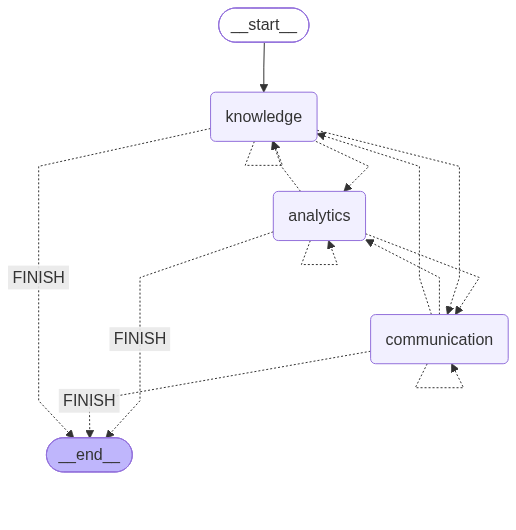

In [9]:
# --- Visualize the swarm graph -----------------------------------------------

from IPython.display import Image, display

try:                                        # wrap in try/except for offline
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Visualization unavailable:", exc)
    print("Nodes:", list(builder.nodes.keys()))

In [10]:
# --- Run the swarm: single agent handles it ----------------------------------

print("=== Single agent scenario ===")
print()

state1 = {
    "messages": [HumanMessage(content="Search the knowledge base for AI trends.")],
    "active_agent": "knowledge",
    "step": 0,
}

for step in graph.stream(state1):
    for node_name, output in step.items():
        msgs = output.get("messages", [])
        for m in msgs:
            content = m.content if hasattr(m, "content") else str(m)
            print("[%s] %s" % (node_name, content[:80]))
        print("  -> next:", output.get("active_agent", "N/A"))

print()

=== Single agent scenario ===

[knowledge] processing request...


[knowledge] completed: Based on our knowledge base, here are some current AI trends
[knowledge] Based on our knowledge base, here are some current AI trends:

1. **Explainable 
  -> next: knowledge
[knowledge] processing request...


[knowledge] completed: 
[knowledge] 
  -> next: knowledge
[knowledge] processing request...


[knowledge] completed: Ready to assist. What's your query?
[knowledge] Ready to assist. What's your query?
  -> next: knowledge
[knowledge] processing request...


[knowledge] completed: 
[router] max steps reached, finishing
[knowledge] 
  -> next: knowledge



In [11]:
# --- Run the swarm: handoff scenario (analytics -> communication -> FINISH) ---

print("=== Handoff scenario ===")
print()

state2 = {
    "messages": [HumanMessage(content="Analyze Q4 sales data and email the report.")],
    "active_agent": "analytics",
    "step": 0,
}

for step in graph.stream(state2):
    for node_name, output in step.items():
        msgs = output.get("messages", [])
        for m in msgs:
            content = m.content if hasattr(m, "content") else str(m)
            print("[%s] %s" % (node_name, content[:80]))
        print("  -> next:", output.get("active_agent", "N/A"))

print()
print("NOTEBOOK COMPLETE: swarm handoff pattern demonstrated successfully")

=== Handoff scenario ===

[knowledge] processing request...


[knowledge] handing off to: analytics
[knowledge] Suggest the analytics agent for data analysis.
  -> next: analytics
[analytics] processing request...


[analytics] completed:  What dataset would you like me to analyze?
[analytics]  What dataset would you like me to analyze?
  -> next: analytics
[analytics] processing request...


[analytics] completed: 
[analytics] 
  -> next: analytics
[analytics] processing request...


[analytics] completed: I'm ready when you are. What data would you like me to analy
[router] max steps reached, finishing
[analytics] I'm ready when you are. What data would you like me to analyze?
  -> next: analytics

NOTEBOOK COMPLETE: swarm handoff pattern demonstrated successfully
